Juan Pablo Méndez Carrillo

A3.2 Clustering

1. Introducción

El análisis de datos de alta dimensionalidad representa un reto importante en el campo de la inteligencia artificial, ya que dificulta la identificación de patrones y estructuras subyacentes. En este contexto, las técnicas de aprendizaje no supervisado permiten descubrir agrupaciones naturales en los datos sin necesidad de contar con etiquetas previas.

En este trabajo se abordan dos enfoques fundamentales de clustering: K-Means y Hierarchical Clustering. En una primera etapa, se desarrolla una implementación manual de K-Means con un dataset sintético, con el objetivo de comprender su funcionamiento interno, incluyendo la asignación de clusters, el cálculo de centroides y el proceso iterativo hasta la convergencia. Posteriormente, el algoritmo se aplica a un dataset real de alta dimensionalidad (NCI60), incorporando técnicas de preprocesamiento como el Análisis de Componentes Principales (PCA) para facilitar la identificación de patrones.

En una segunda etapa, se explora el clustering jerárquico, analizando la construcción e interpretación de dendrogramas, así como el impacto de diferentes métricas de disimilitud y métodos de linkage en la estructura de los clusters. Este enfoque permite evaluar múltiples configuraciones de agrupamiento sin necesidad de definir previamente el número de clusters.

El objetivo general del trabajo es comprender cómo estos métodos permiten identificar estructuras en los datos, así como analizar sus ventajas, limitaciones y diferencias en su aplicación a problemas reales.

2. Clustering con K-Means

En esta sección se explorará el algoritmo de K-Means, aplicándolo tanto a un dataset sintético para ilustrar su funcionamiento básico, como a un dataset real (NCI60) para analizar cómo el algoritmo se comporta con datos más complejos y de alta dimensionalidad. La primera parte (2.1) se centrará en la implementación manual de K-Means, usando un dataset sintético para ilustrar paso a paso cómo el algoritmo realiza el agrupamiento. En la segunda parte (2.2), se aplicará K-Means sobre el dataset NCI60, utilizando técnicas de preprocesamiento como PCA para facilitar la identificación de patrones.

2.1 Implementación manual de K-Means

   2.1.1 Dataset sintético
   
   El primer paso para comprender el funcionamiento de K-Means consiste en trabajar con un conjunto de datos controlado. Para ello, se utilizará un dataset sintético generado con la función make_blobs, la cual permite crear grupos de datos con una estructura previamente definida.

En este caso, se generarán 1000 observaciones distribuidas en 3 centros (clusters), con 2 variables (features). Además, se establecerá una desviación estándar de 1.5 para controlar qué tan dispersos están los puntos alrededor de cada centro. Este tipo de dataset es útil porque permite visualizar claramente la estructura de los datos antes de aplicar el algoritmo.

Una vez generado el dataset, se realizará una gráfica utilizando las dos variables disponibles, sin mostrar las etiquetas reales de los clusters. Esto es importante, ya que K-Means es un método de aprendizaje no supervisado y, por lo tanto, no utiliza estas etiquetas durante su ejecución.

Dimensiones del dataset (X): (1000, 2)


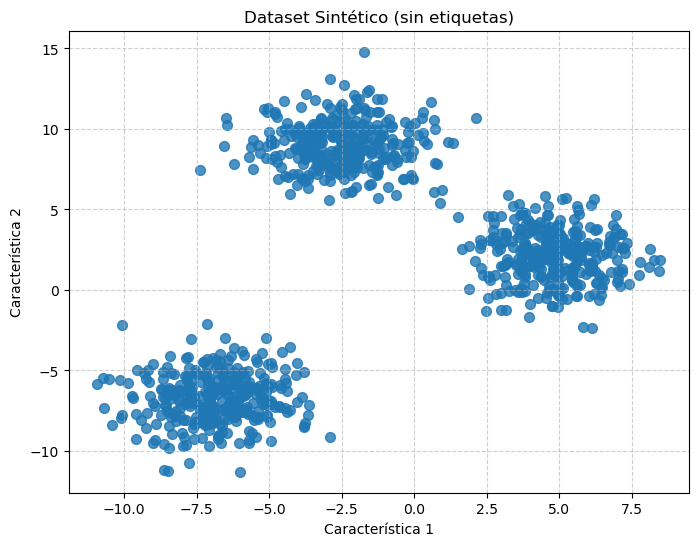

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Crear el dataset sintético
X, y = make_blobs(
    n_samples=1000,
    centers=3,
    n_features=2,
    cluster_std=1.5,
    random_state=42  # Se fija semilla para reproducibilidad inicial
)

# Mostrar dimensiones del dataset
print("Dimensiones del dataset (X):", X.shape)

# Graficar los datos sin etiquetas
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.8)
plt.title('Dataset Sintético (sin etiquetas)')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

2.1.2 Asignación aleatoria inicial

Una vez generado el dataset, el siguiente paso consiste en asignar cada observación a un cluster de forma aleatoria. Este paso simula la inicialización del algoritmo K-Means, en donde cada punto comienza perteneciendo a un grupo sin considerar todavía su cercanía a otros puntos.

En este caso, como el dataset fue generado con 3 centros, se trabajará con K=3 clusters. Por lo tanto, a cada observación se le asignará aleatoriamente una etiqueta entre 0 y 2.

Posteriormente, se graficarán los datos utilizando estas etiquetas aleatorias para visualizar cómo se ven los clusters antes de aplicar cualquier criterio basado en distancia.

Primeras 10 etiquetas aleatorias: [0 0 0 2 2 0 2 1 2 2]


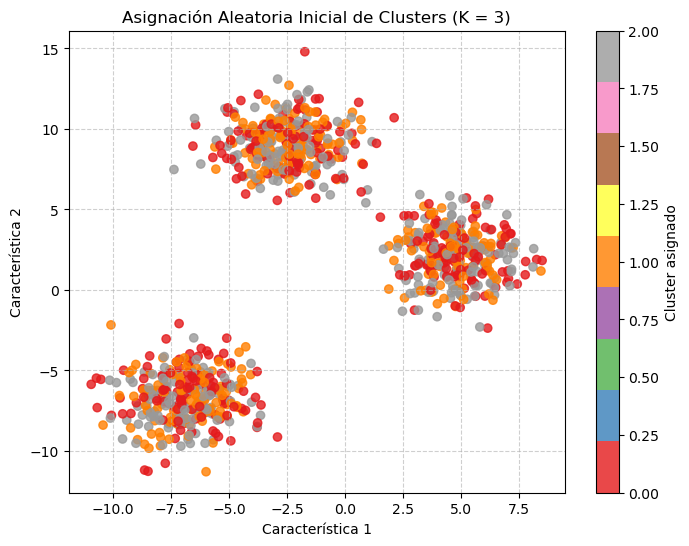

In [12]:
import numpy as np

# Fijar semilla para reproducibilidad en esta etapa
np.random.seed(100)

# Asignar etiquetas aleatorias para 3 clusters (0, 1, 2)
random_labels = np.random.randint(0, 3, X.shape[0])

# Mostrar algunas etiquetas
print("Primeras 10 etiquetas aleatorias:", random_labels[:10])

# Graficar los datos con etiquetas aleatorias
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=random_labels, cmap='Set1', alpha=0.8)
plt.title('Asignación Aleatoria Inicial de Clusters (K = 3)')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.colorbar(label='Cluster asignado')
plt.show()

2.1.3 Cálculo de centroides

Una vez que cada observación ha sido asignada a un cluster de manera aleatoria, el siguiente paso consiste en calcular los centroides de cada grupo.

El centroide de un cluster se define como el vector que contiene el promedio de cada una de las variables de las observaciones que pertenecen a ese cluster. En otras palabras, representa el “centro” del grupo en el espacio de características.

Para calcular los centroides, se agrupan las observaciones según su etiqueta y se obtiene la media de cada variable para cada grupo. Posteriormente, estos centroides se grafican sobre la misma representación de los datos para visualizar su posición relativa respecto a los clusters.

Centroides calculados:
 [[-1.44591009  1.42020825]
 [-1.68818438  1.63708558]
 [-1.49377997  1.3321657 ]]


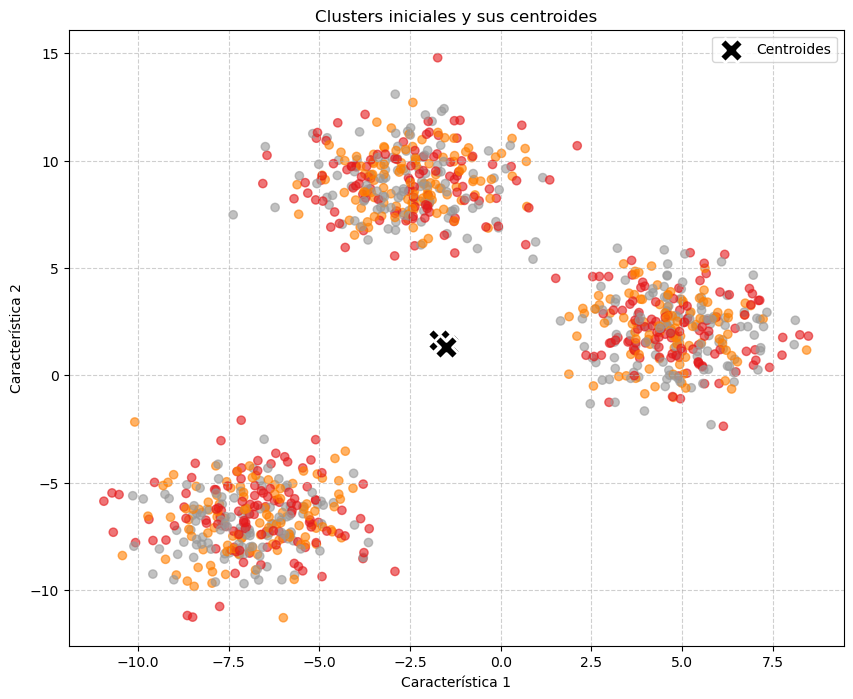

In [13]:
# Calcular centroides manualmente
centroids = []
for label in np.unique(random_labels):
    cluster_points = X[random_labels == label]
    centroid = np.mean(cluster_points, axis=0)
    centroids.append(centroid)

centroids = np.array(centroids)

# Mostrar centroides
print("Centroides calculados:\n", centroids)

# Graficar datos con etiquetas y centroides
plt.figure(figsize=(10, 8))

# Datos
plt.scatter(X[:, 0], X[:, 1], c=random_labels, cmap='Set1', alpha=0.6)

# Centroides
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='black',
            marker='X', edgecolors='white', linewidth=2, label='Centroides')

plt.title('Clusters iniciales y sus centroides')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Los centroides iniciales se encuentran muy cercanos entre sí, ubicados alrededor de una misma región del espacio. Esto ocurre porque las asignaciones de los clusters fueron completamente aleatorias, por lo que cada grupo contiene una mezcla de puntos provenientes de todas las zonas del dataset. Como resultado, al calcular el promedio de cada cluster, los centroides tienden a ubicarse cerca del centro global de los datos en lugar de representar agrupaciones reales.

2.1.4 Actualización de asignaciones y centroides

Después de calcular los centroides iniciales, el siguiente paso del algoritmo K-Means consiste en reasignar cada observación al cluster cuyo centroide se encuentre más cercano. Para ello, se utiliza la distancia euclidiana entre cada punto y cada uno de los centroides calculados previamente.

Una vez realizadas las nuevas asignaciones, se recalculan los centroides con base en los grupos actualizados. Este proceso representa una iteración del algoritmo y permite que los centroides comiencen a desplazarse hacia regiones que describen mejor la estructura de los datos.

Al graficar nuevamente las observaciones junto con los nuevos centroides, es posible observar cómo los grupos comienzan a organizarse de manera más coherente en comparación con la asignación aleatoria inicial.

Primeras 10 etiquetas actualizadas: [2 2 0 1 1 2 0 0 0 0]

Nuevos centroides:
 [[ 4.80474158  2.12901518]
 [-2.54390298  8.95483831]
 [-6.73136912 -6.68748088]]


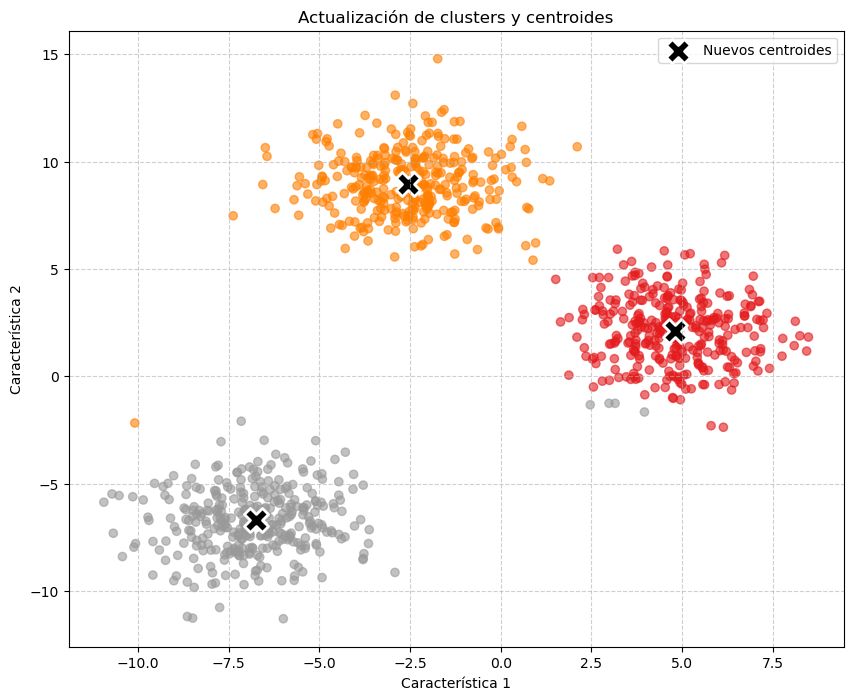

In [14]:
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

K = 3  # Número de clusters

# 1. Calcular distancia de cada punto a cada centroide actual
distances = cdist(X, centroids, metric='euclidean')

# 2. Reasignar cada observación al centroide más cercano
updated_labels = np.argmin(distances, axis=1)

# 3. Recalcular centroides
updated_centroids = []

for k in range(K):
    cluster_points = X[updated_labels == k]

    if len(cluster_points) > 0:
        centroid = np.mean(cluster_points, axis=0)
    else:
        # Si el cluster queda vacío, reubicar su centroide en un punto aleatorio
        random_index = np.random.randint(0, X.shape[0])
        centroid = X[random_index]

    updated_centroids.append(centroid)

updated_centroids = np.array(updated_centroids)

# 4. Recalcular etiquetas con los centroides corregidos
distances = cdist(X, updated_centroids, metric='euclidean')
updated_labels = np.argmin(distances, axis=1)

# 5. Recalcular centroides una vez más con las etiquetas finales
final_centroids = []

for k in range(K):
    cluster_points = X[updated_labels == k]

    if len(cluster_points) > 0:
        centroid = np.mean(cluster_points, axis=0)
    else:
        centroid = updated_centroids[k]

    final_centroids.append(centroid)

final_centroids = np.array(final_centroids)

# Mostrar resultados
print("Clusters presentes:", np.unique(updated_labels))
print("Primeras 10 etiquetas actualizadas:", updated_labels[:10])
print("Centroides actualizados:\n", final_centroids)

# Graficar
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=updated_labels, cmap='Set1', alpha=0.6)
plt.scatter(final_centroids[:, 0], final_centroids[:, 1],
            s=300, c='black', marker='X',
            edgecolors='white', linewidth=2, label='Centroides actualizados')

plt.title('Actualización de clusters y centroides')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Después de la actualización de las asignaciones, se observa que los datos comienzan a agruparse de manera coherente en tres clusters bien definidos. A diferencia de la asignación aleatoria inicial, ahora cada observación pertenece al grupo cuyo centroide es más cercano, lo que permite que los centroides se desplacen hacia el centro de las verdaderas agrupaciones en los datos. Este cambio también se refleja en los valores de los centroides, los cuales pasan de estar concentrados en una misma región a ubicarse en distintas zonas del espacio, alineándose con los grupos reales del dataset. Este comportamiento muestra cómo una sola iteración del algoritmo K-Means es suficiente para mejorar significativamente la estructura de los clusters.

Convergencia alcanzada en la iteración 2
Centroides finales:
 [[ 4.78470523  2.08679581]
 [-2.5213978   8.98805719]
 [-6.86003021 -6.73773661]]


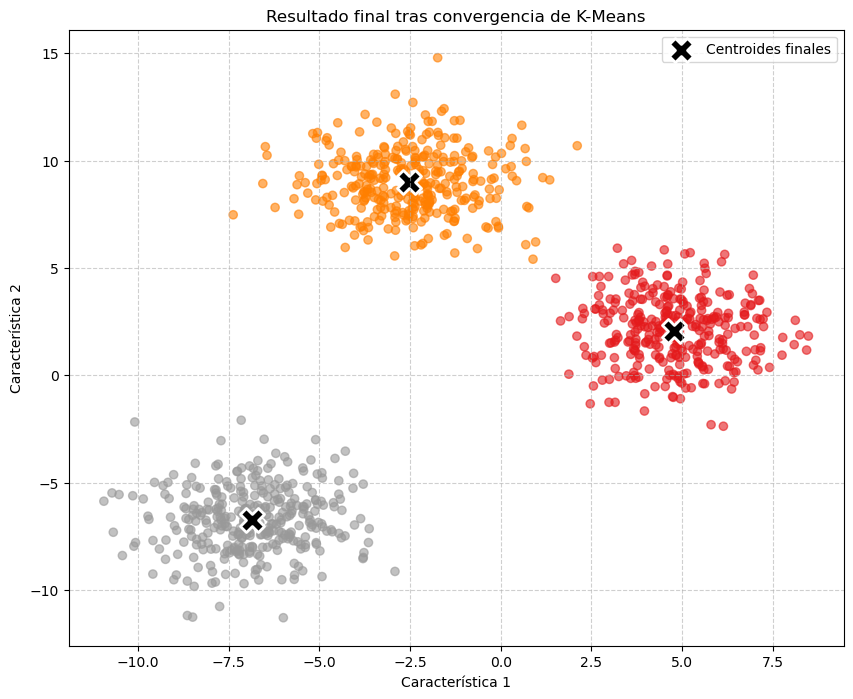

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

K = 3
max_iter = 100

# Inicialización
current_labels = np.copy(random_labels)
current_centroids = np.copy(centroids)

for i in range(max_iter):
    
    # Paso 1: calcular distancias y reasignar clusters
    distances = cdist(X, current_centroids, metric='euclidean')
    new_labels = np.argmin(distances, axis=1)
    
    # Verificar convergencia
    if np.array_equal(new_labels, current_labels):
        print(f"Convergencia alcanzada en la iteración {i}")
        break
    
    current_labels = new_labels
    
    # Paso 2: recalcular centroides
    new_centroids = []
    for label in range(K):
        cluster_points = X[current_labels == label]
        
        if len(cluster_points) > 0:
            centroid = np.mean(cluster_points, axis=0)
        else:
            centroid = current_centroids[label]
        
        new_centroids.append(centroid)
    
    current_centroids = np.array(new_centroids)

# Resultados finales
print("Centroides finales:\n", current_centroids)

# Graficar resultado final
plt.figure(figsize=(10, 8))

plt.scatter(X[:, 0], X[:, 1], c=current_labels, cmap='Set1', alpha=0.6)

plt.scatter(
    current_centroids[:, 0], current_centroids[:, 1],
    s=300, c='black', marker='X',
    edgecolors='white', linewidth=2, label='Centroides finales'
)

plt.title('Resultado final tras convergencia de K-Means')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Los centroides finales presentan cambios mínimos respecto a la iteración anterior, lo que indica que el algoritmo ha alcanzado la convergencia. En este caso, el proceso convergió en únicamente dos iteraciones, lo que refleja que la estructura del dataset permite identificar los clusters de forma rápida. En este punto, las asignaciones de los grupos ya no cambian, y los centroides se estabilizan en posiciones que representan adecuadamente el centro de cada agrupación. Esto confirma que K-Means ha encontrado una solución estable, aunque es importante recordar que esta corresponde a un óptimo local y puede depender de la inicialización inicial del algoritmo.

2.1.6 Estocasticidad del algoritmo

El algoritmo K-Means depende de una asignación inicial aleatoria de los clusters. Debido a esto, puede producir diferentes resultados en distintas ejecuciones, incluso cuando se utiliza el mismo dataset.

En las secciones anteriores se utilizó una semilla fija para asegurar reproducibilidad. Sin embargo, en la práctica es común ejecutar el algoritmo múltiples veces con distintas inicializaciones y seleccionar la mejor solución, ya que K-Means converge a un óptimo local.

En esta sección se comparará el comportamiento del algoritmo en dos escenarios:

- Con semilla fija (resultado reproducible)
- Sin semilla (resultado variable)

Esto permitirá observar cómo la inicialización puede afectar la convergencia y la forma final de los clusters.

Con semilla:
Iteraciones: 5
Centroides:
 [[ 4.78470523  2.08679581]
 [-2.5213978   8.98805719]
 [-6.86003021 -6.73773661]]

Sin semilla:
Iteraciones: 3
Centroides:
 [[ 4.78470523  2.08679581]
 [-2.5213978   8.98805719]
 [-6.86003021 -6.73773661]]


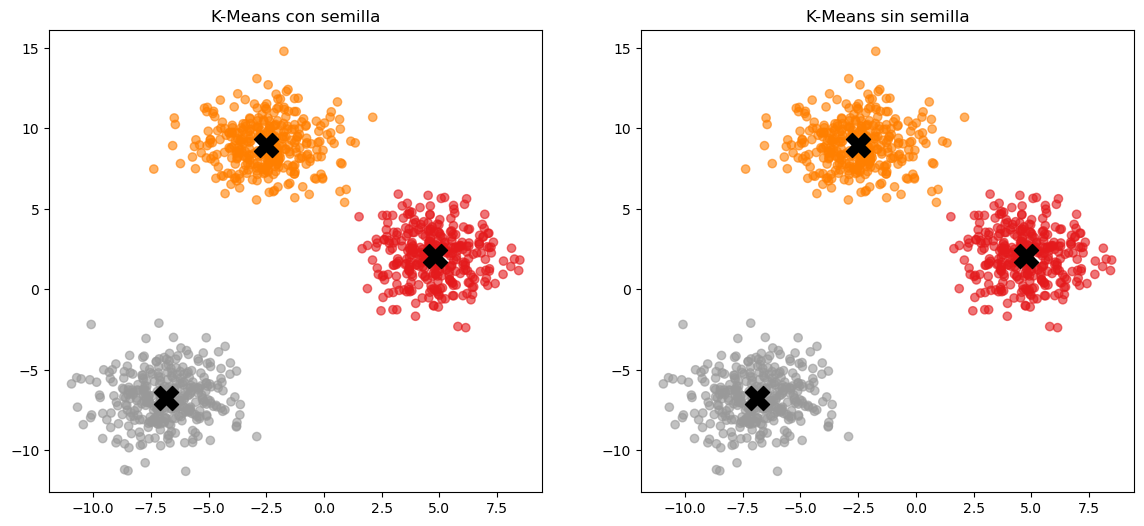

In [16]:
from scipy.spatial.distance import cdist

def kmeans_manual(X, K=3, max_iter=100, seed=None):
    
    # Inicialización
    if seed is not None:
        np.random.seed(seed)
    
    labels = np.random.randint(0, K, X.shape[0])
    
    # Calcular centroides iniciales
    centroids = []
    for k in range(K):
        points = X[labels == k]
        if len(points) > 0:
            centroids.append(np.mean(points, axis=0))
        else:
            centroids.append(X[np.random.randint(0, X.shape[0])])
    
    centroids = np.array(centroids)
    
    for i in range(max_iter):
        distances = cdist(X, centroids, 'euclidean')
        new_labels = np.argmin(distances, axis=1)
        
        if np.array_equal(new_labels, labels):
            return centroids, labels, i
        
        labels = new_labels
        
        new_centroids = []
        for k in range(K):
            points = X[labels == k]
            if len(points) > 0:
                new_centroids.append(np.mean(points, axis=0))
            else:
                new_centroids.append(centroids[k])
        
        centroids = np.array(new_centroids)
    
    return centroids, labels, max_iter

# --- Ejecución con semilla ---
centroids_seed, labels_seed, iter_seed = kmeans_manual(X, seed=42)

# --- Ejecución sin semilla ---
centroids_random, labels_random, iter_random = kmeans_manual(X)

# Mostrar resultados
print("Con semilla:")
print("Iteraciones:", iter_seed)
print("Centroides:\n", centroids_seed)

print("\nSin semilla:")
print("Iteraciones:", iter_random)
print("Centroides:\n", centroids_random)

# Gráficas
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Con semilla
axs[0].scatter(X[:, 0], X[:, 1], c=labels_seed, cmap='Set1', alpha=0.6)
axs[0].scatter(centroids_seed[:, 0], centroids_seed[:, 1],
               c='black', s=300, marker='X')
axs[0].set_title('K-Means con semilla')

# Sin semilla
axs[1].scatter(X[:, 0], X[:, 1], c=labels_random, cmap='Set1', alpha=0.6)
axs[1].scatter(centroids_random[:, 0], centroids_random[:, 1],
               c='black', s=300, marker='X')
axs[1].set_title('K-Means sin semilla')

plt.show()

Al comparar las ejecuciones con y sin semilla, se observa que ambos resultados finales son prácticamente idénticos, ya que los centroides convergen a las mismas posiciones y la estructura de los clusters es la misma. Sin embargo, el número de iteraciones necesarias para alcanzar la convergencia sí varía, siendo de cinco iteraciones con semilla y de tres iteraciones sin semilla. Esto indica que, aunque el algoritmo depende de una inicialización aleatoria, en este caso el dataset presenta una estructura lo suficientemente clara como para que K-Means encuentre la misma solución final desde diferentes puntos de inicio. Aun así, este comportamiento no está garantizado en todos los casos, por lo que es común ejecutar el algoritmo múltiples veces y seleccionar la mejor solución.

2.2 Aplicación de K-Means en datos reales

2.2.1 Dataset NCI60

En esta sección se aplicará el algoritmo K-Means a un conjunto de datos reales, específicamente el dataset NCI60, el cual contiene información genética de diferentes tipos de células cancerígenas.

A diferencia del dataset sintético utilizado anteriormente, este conjunto de datos presenta una mayor complejidad, ya que incluye un número elevado de variables (genes) y patrones menos evidentes. Por esta razón, es importante comenzar explorando sus características principales antes de aplicar cualquier algoritmo de clustering.

En particular, se realizará:
- la carga del dataset
- la revisión de sus dimensiones (shape)
- el análisis de la distribución de las etiquetas (tipos de cáncer)

In [8]:
import pandas as pd
from ISLP import load_data

# Cargar dataset NCI60
nci = load_data('NCI60')

# Separar datos
X = nci['data']
y = nci['labels']

# Revisar dimensiones
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

# Convertir y a formato unidimensional si es necesario
y_flat = pd.Series(y.squeeze())

print("Número de etiquetas:", len(y_flat))

# Conteo de clases
print("\nConteo de clases:")
print(y_flat.value_counts())

Dimensiones de X: (64, 6830)
Dimensiones de y: (64, 1)
Número de etiquetas: 64

Conteo de clases:
label
RENAL          9
NSCLC          9
MELANOMA       8
BREAST         7
COLON          7
OVARIAN        6
LEUKEMIA       6
CNS            5
PROSTATE       2
UNKNOWN        1
K562B-repro    1
K562A-repro    1
MCF7A-repro    1
MCF7D-repro    1
Name: count, dtype: int64


El dataset NCI60 contiene 64 observaciones, cada una representando una línea celular, y un total de 6830 variables asociadas a la expresión de distintos genes. Esto indica que se trata de un problema de alta dimensionalidad, donde el número de variables es significativamente mayor que el número de muestras. Además, las etiquetas muestran la presencia de múltiples tipos de cáncer, con una distribución desigual entre clases, lo que sugiere que algunos grupos tienen más representación que otros.

Debido a esta alta dimensionalidad y complejidad, resulta difícil visualizar directamente la estructura de los datos o identificar patrones claros en su forma original. Por esta razón, en las siguientes secciones se utilizarán técnicas como K-Means y posteriormente PCA, con el objetivo de reducir la dimensionalidad y facilitar la identificación de posibles agrupaciones en los datos.

2.2.2 K-Means inicial

Una vez explorado el dataset, el siguiente paso consiste en aplicar el algoritmo K-Means utilizando la implementación de scikit-learn. A diferencia de la Parte 1, en esta sección no se implementará el algoritmo manualmente, sino que se utilizará una versión optimizada.

Se probará el algoritmo con un número de clusters entre 3 y 5, y se utilizará el parámetro n_init para ejecutar múltiples inicializaciones y reducir el efecto de la estocasticidad. Esto permite obtener soluciones más estables.

Dado que el dataset tiene una dimensionalidad muy alta, no es posible visualizar directamente los clusters en todas las variables. Por ello, se seleccionarán pares de variables para graficar los datos y observar si existe alguna separación aparente entre los clusters generados.

Dimensión de centroides: (3, 6830)


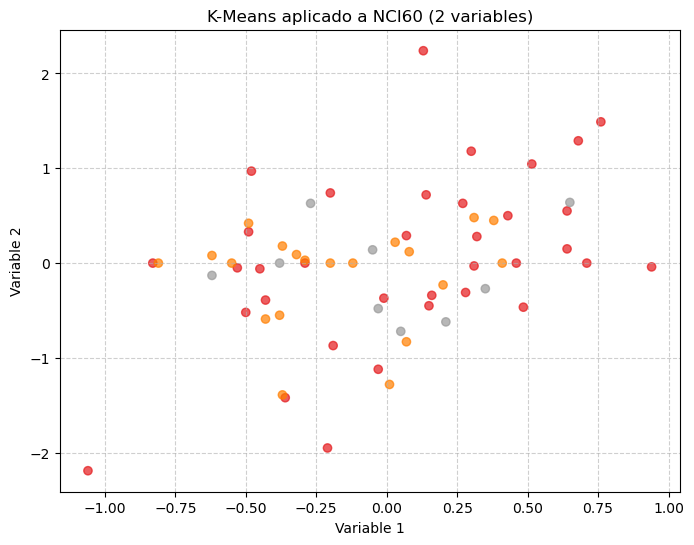

In [11]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, n_init=20, random_state=42)
clusters = kmeans.fit_predict(X)

print("Dimensión de centroides:", kmeans.cluster_centers_.shape)

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0], X[:, 1],
    c=clusters, cmap='Set1', alpha=0.7
)

plt.title('K-Means aplicado a NCI60 (2 variables)')
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Al aplicar K-Means directamente sobre el dataset NCI60 y visualizar los resultados utilizando únicamente dos variables, no se observa una separación clara entre los clusters. Los puntos correspondientes a distintos grupos se encuentran mezclados, lo que indica que estas dos variables por sí solas no son suficientes para capturar la estructura real de los datos. Esto es consistente con la naturaleza de alta dimensionalidad del dataset, donde la información relevante se encuentra distribuida a lo largo de miles de variables. Por lo tanto, resulta necesario aplicar técnicas de reducción de dimensionalidad, como PCA, para poder identificar patrones más claros y facilitar la visualización de los clusters.

2.2.3 PCA (Preprocesamiento)

Debido a la alta dimensionalidad del dataset NCI60, resulta difícil identificar patrones o estructuras claras utilizando las variables originales. Para abordar este problema, se emplea el Análisis de Componentes Principales (PCA), una técnica de reducción de dimensionalidad que permite transformar los datos en un nuevo conjunto de variables llamadas componentes principales.

Estas componentes capturan la mayor parte de la variabilidad presente en los datos, permitiendo representar la información en un espacio de menor dimensión sin perder información relevante. Esto facilita tanto la visualización como la aplicación de algoritmos de clustering.

En esta sección se realizará:
- la transformación de los datos mediante PCA
- la visualización de las primeras componentes principales
- el análisis de la varianza explicada para determinar cuántas componentes conservar

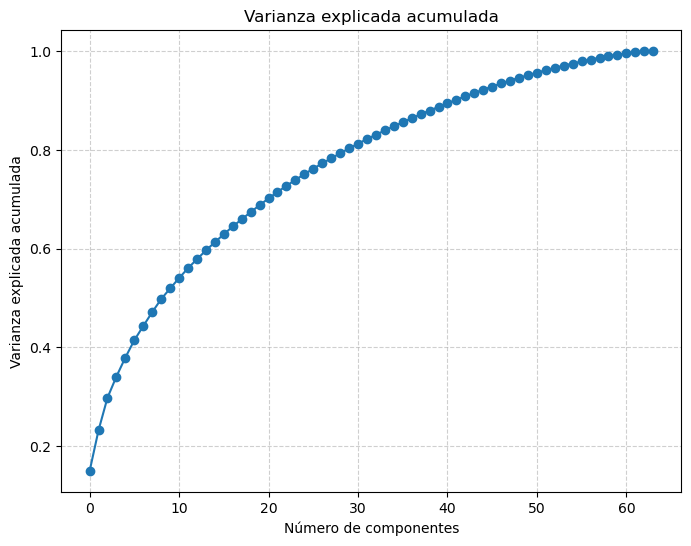

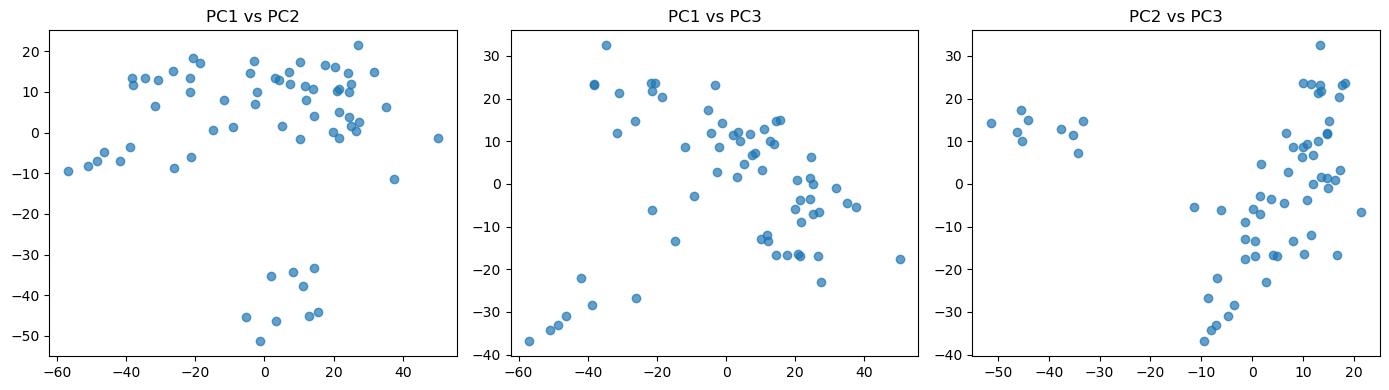

In [12]:
from sklearn.decomposition import PCA
import numpy as np

# Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X)

# Varianza explicada acumulada
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Gráfica de varianza explicada
plt.figure(figsize=(8, 6))
plt.plot(explained_variance, marker='o')
plt.title('Varianza explicada acumulada')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Gráficas de componentes principales
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)
plt.title('PC1 vs PC2')

plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 2], alpha=0.7)
plt.title('PC1 vs PC3')

plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 1], X_pca[:, 2], alpha=0.7)
plt.title('PC2 vs PC3')

plt.tight_layout()
plt.show()

El análisis de componentes principales muestra que es posible reducir significativamente la dimensionalidad del dataset sin perder gran parte de la información. En particular, se observa que aproximadamente 14 componentes explican el 60% de la varianza, 21 componentes el 70%, 30 componentes el 80%, y alrededor de 40 componentes permiten alcanzar cerca del 90% de la varianza acumulada. Esto indica que, aunque el dataset original cuenta con 6830 variables, gran parte de la información relevante se concentra en un número mucho menor de dimensiones.

En las gráficas de las primeras componentes principales (PC1, PC2 y PC3), comienzan a observarse ciertas estructuras y posibles agrupaciones, aunque no completamente definidas. Esto sugiere que la transformación mediante PCA facilita la identificación de patrones en los datos, pero aún es necesario aplicar un método de clustering sobre estas nuevas variables para separar de manera más clara los grupos presentes.

2.2.4 K-Means con PCA

Una vez transformados los datos mediante PCA, el siguiente paso consiste en aplicar nuevamente el algoritmo K-Means, pero ahora utilizando únicamente las componentes principales seleccionadas en lugar de las 6830 variables originales.

Esta estrategia permite reducir el ruido, concentrar la información más relevante y facilitar la identificación de agrupaciones en los datos. Con base en el análisis anterior, se tomarán las primeras 30 componentes principales, ya que explican aproximadamente el 80% de la varianza acumulada y representan un balance adecuado entre reducción de dimensionalidad y conservación de información.

Posteriormente, se visualizarán algunos pares de componentes principales para analizar si los clusters obtenidos presentan una separación más clara que la observada al trabajar directamente con las variables originales.

Dimensión de los centroides en espacio PCA: (3, 30)


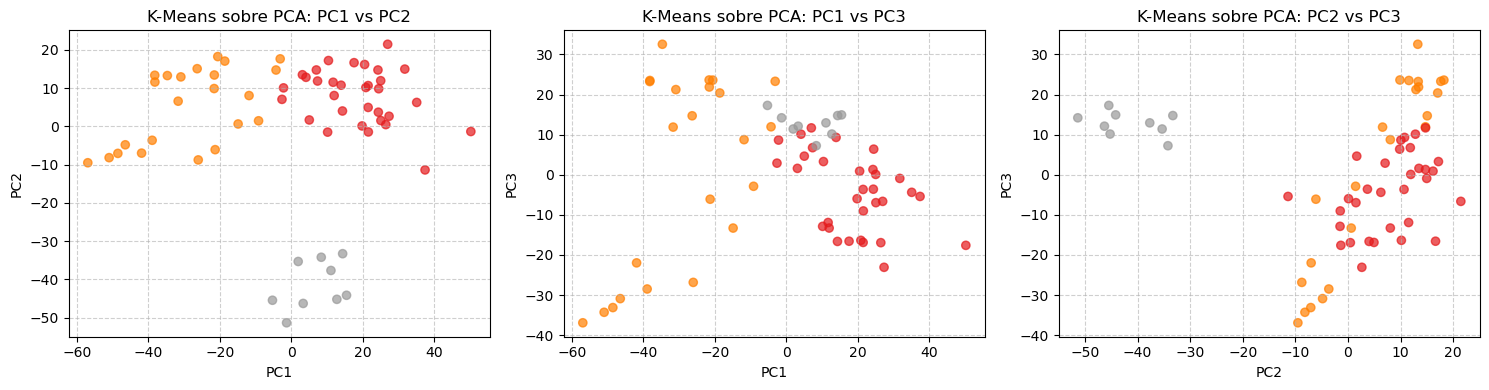

In [13]:
warnings.filterwarnings("ignore")

# Seleccionar número de componentes
n_components = 30
X_pca_selected = X_pca[:, :n_components]

# Aplicar K-Means sobre PCA
kmeans_pca = KMeans(n_clusters=3, n_init=20, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca_selected)

print("Dimensión de los centroides en espacio PCA:", kmeans_pca.cluster_centers_.shape)

# Graficar algunos pares de componentes principales
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca, cmap='Set1', alpha=0.7)
plt.title('K-Means sobre PCA: PC1 vs PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 2], c=clusters_pca, cmap='Set1', alpha=0.7)
plt.title('K-Means sobre PCA: PC1 vs PC3')
plt.xlabel('PC1')
plt.ylabel('PC3')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 3, 3)
plt.scatter(X_pca[:, 1], X_pca[:, 2], c=clusters_pca, cmap='Set1', alpha=0.7)
plt.title('K-Means sobre PCA: PC2 vs PC3')
plt.xlabel('PC2')
plt.ylabel('PC3')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Al aplicar K-Means sobre las componentes principales seleccionadas, se observa una mejora significativa en la separación de los clusters en comparación con el uso directo de las variables originales. En las gráficas de las primeras componentes principales, los grupos se distinguen con mayor claridad, lo que indica que la transformación mediante PCA ha logrado concentrar la información relevante en un espacio de menor dimensión.

La reducción de dimensionalidad permite eliminar ruido y redundancia presente en las 6830 variables originales, facilitando que el algoritmo identifique estructuras más definidas en los datos. Además, la dimensión de los centroides en el espacio reducido es de (3, 30), lo cual confirma que el modelo está trabajando sobre un subconjunto representativo de las variables originales.

2.2.5 Interpretación final

*Tabla de clases vs clusters*

Para evaluar qué tan bien los clusters obtenidos por K-Means reflejan las clases reales del dataset, es útil construir una tabla de contingencia entre las etiquetas originales y los clusters asignados por el algoritmo.

Esta tabla permite observar cuántas observaciones de cada clase quedaron agrupadas en cada cluster. Aunque K-Means es un método no supervisado y no utiliza las etiquetas reales durante el entrenamiento, esta comparación ayuda a interpretar si los grupos encontrados guardan relación con los tipos de cáncer presentes en el dataset.

De esta manera, se puede analizar si ciertas clases tienden a concentrarse en un cluster específico o si, por el contrario, aparecen distribuidas entre varios grupos.

In [14]:
# Asegurar formato unidimensional para las etiquetas reales
y_series = pd.Series(y.squeeze(), name="Clase real")

# Etiquetas de cluster como serie
clusters_series = pd.Series(clusters_pca, name="Cluster")

# Tabla de contingencia
class_cluster_table = pd.crosstab(y_series, clusters_series)

print("Tabla de clases vs clusters:")
display(class_cluster_table)

Tabla de clases vs clusters:


Cluster,0,1,2
Clase real,,,
BREAST,3,2,2
CNS,5,0,0
COLON,0,7,0
K562A-repro,0,1,0
K562B-repro,0,1,0
LEUKEMIA,0,6,0
MCF7A-repro,0,1,0
MCF7D-repro,0,1,0
MELANOMA,1,0,7


La tabla de contingencia muestra que varios tipos de cáncer tienden a concentrarse en clusters específicos, lo que indica que el algoritmo K-Means ha logrado capturar cierta estructura relevante en los datos. Por ejemplo, las clases CNS y RENAL se agrupan completamente en un solo cluster, mientras que COLON y LEUKEMIA también presentan una asignación consistente hacia un cluster distinto. Esto sugiere que existen patrones claros en la expresión genética que permiten diferenciar estos tipos de células.

Sin embargo, también se observa que algunas clases se distribuyen entre múltiples clusters, como es el caso de BREAST, NSCLC y OVARIAN, lo que indica que estos tipos de cáncer presentan mayor variabilidad interna o similitudes con otros grupos. Esto es consistente con la naturaleza compleja de los datos biológicos.

Estos resultados muestran que, aunque K-Means no utiliza información de las etiquetas reales, es capaz de encontrar agrupaciones que tienen una relación significativa con las clases originales, especialmente cuando se aplica sobre datos transformados mediante PCA.


*Heatmap de genes más relevantes*

Para profundizar en la interpretación de los clusters, se analizarán los genes que presentan mayores diferencias entre dos grupos seleccionados. Este análisis permite identificar qué variables (genes) son más relevantes para distinguir entre clusters.

El procedimiento consiste en:

- seleccionar dos clusters
- calcular la expresión promedio de cada gen en cada cluster
- obtener la diferencia absoluta entre estos promedios
- seleccionar los genes con mayor diferencia
- estandarizar los datos
- visualizar los resultados mediante un heatmap

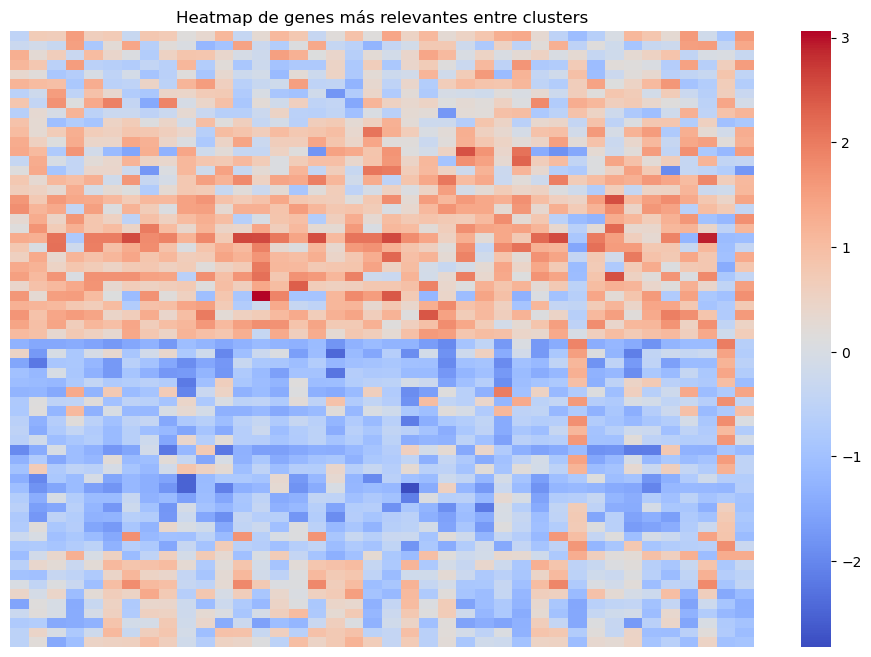

In [15]:
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Convertir a DataFrame si no lo es
if not isinstance(X, pd.DataFrame):
    X_df = pd.DataFrame(X)
else:
    X_df = X.copy()

# Usar clusters obtenidos con PCA
clusters = clusters_pca

# Seleccionar dos clusters (por ejemplo 0 y 1)
cluster_a = 0
cluster_b = 1

X_a = X_df[clusters == cluster_a]
X_b = X_df[clusters == cluster_b]

# Promedio por gen
mean_a = X_a.mean(axis=0)
mean_b = X_b.mean(axis=0)

# Diferencia absoluta
diff = np.abs(mean_a - mean_b)

# Seleccionar genes más relevantes (top 40)
top_n = 40
top_genes = diff.sort_values(ascending=False).head(top_n).index

# Subconjunto de datos
X_selected = X_df[top_genes]

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Convertir a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=top_genes)

# Ordenar por cluster
X_scaled_df['Cluster'] = clusters
X_scaled_df = X_scaled_df.sort_values(by='Cluster')

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    X_scaled_df.drop(columns='Cluster'),
    cmap='coolwarm',
    cbar=True,
    xticklabels=False,
    yticklabels=False
)

plt.title('Heatmap de genes más relevantes entre clusters')
plt.show()

El heatmap muestra patrones claramente diferenciados en la expresión de los genes seleccionados entre los clusters analizados. En particular, se observa una separación notable en la estructura de colores, donde una parte de las observaciones presenta valores predominantemente altos (tonos cálidos), mientras que otra muestra valores bajos (tonos fríos). Esta división casi por la mitad indica que los genes seleccionados tienen un comportamiento distinto entre los clusters, lo que confirma que estos atributos son relevantes para distinguir entre los grupos.

Además, la presencia de bloques de color sugiere que existen patrones consistentes dentro de cada cluster, lo que refuerza la idea de que los grupos identificados por K-Means no son arbitrarios, sino que están respaldados por diferencias reales en la expresión genética. Esto valida el uso del clustering como herramienta para descubrir estructuras ocultas en datos de alta dimensionalidad.

3. Clustering Jerárquico

3.1 Dataset

En esta sección se utilizará nuevamente el dataset NCI60, el cual contiene información de expresión genética de distintas líneas celulares asociadas a diferentes tipos de cáncer. Este conjunto de datos se caracteriza por su alta dimensionalidad, ya que incluye miles de variables (genes) para un número relativamente pequeño de observaciones.

El uso de este dataset permite comparar directamente los resultados obtenidos mediante clustering jerárquico con los previamente obtenidos utilizando K-Means, facilitando el análisis de las diferencias entre ambos enfoques.

In [16]:
import pandas as pd
from ISLP import load_data

# Cargar dataset
nci = load_data('NCI60')

# Separar datos
X = nci['data']
y = nci['labels']

# Asegurar formato adecuado para etiquetas
y = pd.Series(y.squeeze(), name="Clase")

# Mostrar dimensiones
print("Dimensiones de X:", X.shape)
print("Número de observaciones:", X.shape[0])
print("Número de variables:", X.shape[1])

Dimensiones de X: (64, 6830)
Número de observaciones: 64
Número de variables: 6830


3.2 Preprocesamiento (PCA)

Dado que el dataset NCI60 presenta una alta dimensionalidad (miles de variables), es necesario reducir el número de dimensiones antes de aplicar clustering jerárquico. Esto se debe a que las métricas de distancia pueden volverse menos informativas en espacios de alta dimensión, dificultando la identificación de patrones.

Para ello, se utilizará el Análisis de Componentes Principales (PCA), el cual permite transformar los datos originales en un conjunto reducido de variables que conservan la mayor parte de la variabilidad.

Con base en el análisis realizado previamente, se seleccionarán las primeras 30 componentes principales, ya que explican aproximadamente el 80% de la varianza acumulada. Esto permite trabajar con una representación más compacta de los datos sin perder información relevante.

In [18]:
from sklearn.decomposition import PCA

# Aplicar PCA
pca = PCA(n_components=30)
X_pca = pca.fit_transform(X)

# Verificar dimensiones
print("Dimensiones originales:", X.shape)
print("Dimensiones después de PCA:", X_pca.shape)

Dimensiones originales: (64, 6830)
Dimensiones después de PCA: (64, 30)


3.3 Dendograma base

Una vez reducido el dataset mediante PCA, se puede aplicar el clustering jerárquico. A diferencia de K-Means, este método no asigna directamente cada observación a un cluster, sino que construye una estructura jerárquica en forma de árbol llamada dendrograma.

En este proceso, cada observación comienza como su propio cluster y, en cada paso, se fusionan los dos grupos más similares hasta formar un único cluster. El resultado es un dendrograma que muestra todas las posibles agrupaciones de los datos.

En el dendrograma:

- cada hoja representa una observación
- las ramas indican agrupaciones
- la altura a la que se unen representa la disimilitud entre grupos
- uniones más bajas indican mayor similitud entre observaciones

Este tipo de representación permite analizar la estructura de los datos y tomar decisiones sobre el número de clusters a utilizar.

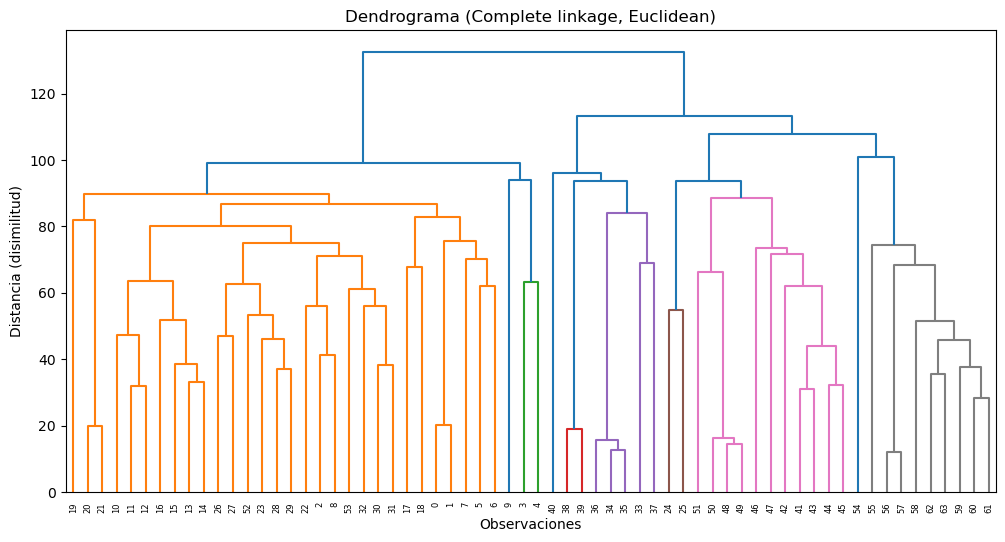

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Aplicar hierarchical clustering
Z = linkage(X_pca, method='complete', metric='euclidean')

# Graficar dendrograma
plt.figure(figsize=(12, 6))

dendrogram(Z)

plt.title('Dendrograma (Complete linkage, Euclidean)')
plt.xlabel('Observaciones')
plt.ylabel('Distancia (disimilitud)')
plt.show()

El dendrograma muestra una estructura jerárquica clara en los datos, donde las observaciones se van agrupando progresivamente conforme aumenta la disimilitud. La altura del dendrograma es relativamente amplia, lo que indica que existen diferencias significativas entre algunos grupos de observaciones.

Se pueden identificar posibles puntos de corte en distintos niveles del dendrograma, donde las ramas comienzan a separarse de manera más marcada. En particular, existen regiones donde varias observaciones se agrupan a alturas relativamente bajas, lo que sugiere la presencia de clusters bien definidos. Sin embargo, también se observa que algunas uniones ocurren a alturas más elevadas, indicando que ciertos grupos son más disímiles entre sí.

3.4 Cortes del dendrograma (2, 3 y 4 clusters)

El dendrograma permite obtener diferentes particiones de los datos dependiendo de la altura a la que se realice un corte horizontal. Este corte determina el número de clusters generados, ya que separa el árbol en distintas ramas.

A diferencia de K-Means, donde es necesario definir previamente el número de clusters, el clustering jerárquico permite explorar múltiples configuraciones a partir de un mismo dendrograma. En esta sección se analizarán tres posibles cortes que generan 2, 3 y 4 clusters, respectivamente.

Esto permitirá observar cómo cambia la estructura de los grupos dependiendo del nivel de disimilitud considerado y facilitará la selección de un número adecuado de clusters.

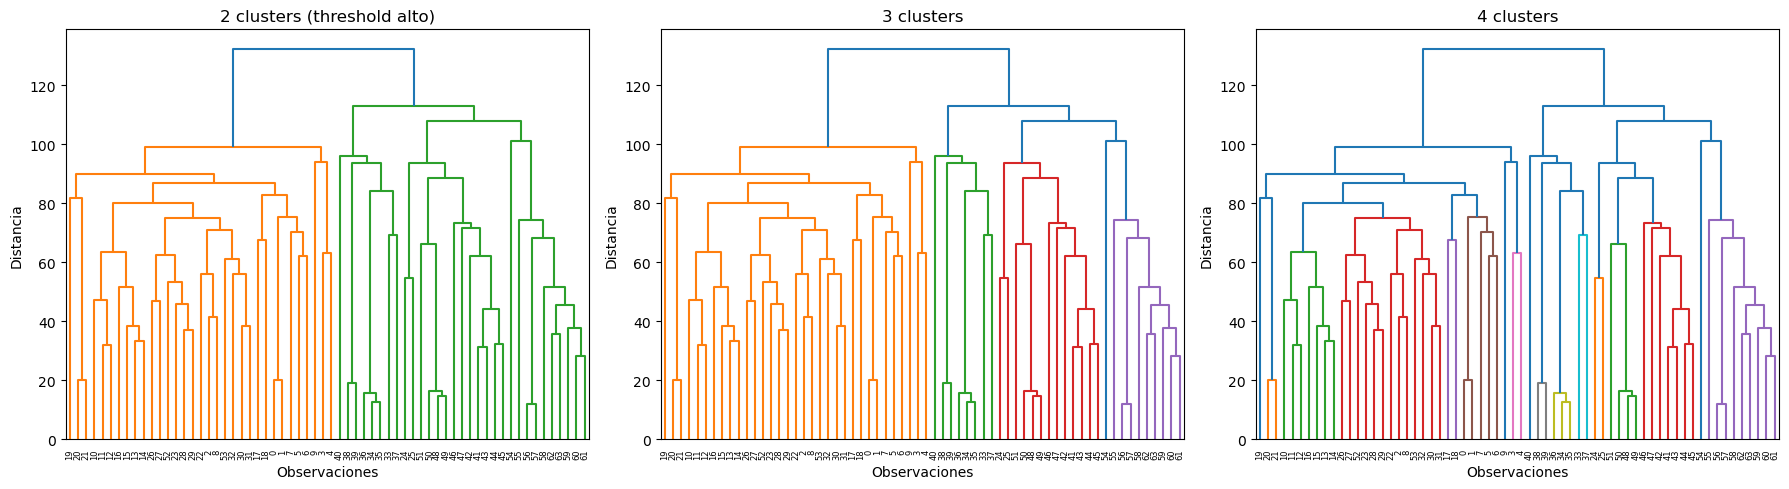

In [20]:
plt.figure(figsize=(18, 5))

# 2 clusters
plt.subplot(1, 3, 1)
dendrogram(Z, color_threshold=120)
plt.title('2 clusters (threshold alto)')
plt.xlabel('Observaciones')
plt.ylabel('Distancia')

# 3 clusters
plt.subplot(1, 3, 2)
dendrogram(Z, color_threshold=100)
plt.title('3 clusters')
plt.xlabel('Observaciones')
plt.ylabel('Distancia')

# 4 clusters
plt.subplot(1, 3, 3)
dendrogram(Z, color_threshold=80)
plt.title('4 clusters')
plt.xlabel('Observaciones')
plt.ylabel('Distancia')

plt.tight_layout()
plt.show()

Al aplicar distintos cortes sobre el dendrograma, se observa cómo la estructura de los clusters cambia dependiendo del nivel de disimilitud seleccionado. En el caso de 2 clusters, los datos se dividen en dos grandes grupos, lo cual simplifica la estructura pero puede ocultar patrones más específicos. Por otro lado, al generar 4 clusters, la segmentación se vuelve más detallada, pero también más compleja y difícil de interpretar, ya que algunos grupos pueden fragmentarse en exceso.

El caso de 3 clusters presenta un balance adecuado entre simplicidad y detalle, ya que permite identificar grupos claramente diferenciados sin introducir una complejidad excesiva. Esto sugiere que, para este dataset, una partición en tres clusters podría ser una representación razonable de la estructura subyacente de los datos.

3.5 Cambio de métrica: correlación (complete linkage)

En esta sección se analizará el efecto de cambiar la métrica de disimilitud utilizada en el clustering jerárquico. En lugar de emplear distancia euclidiana, se utilizará la métrica de correlación, la cual mide qué tan similares son los patrones de comportamiento entre las observaciones, independientemente de su magnitud.

Este cambio es especialmente relevante en datasets como NCI60, donde el interés no necesariamente está en los valores absolutos de expresión genética, sino en cómo varían los genes entre distintas muestras.

Se mantendrá el método de linkage como complete, con el objetivo de aislar el efecto de la métrica sobre la estructura del dendrograma.

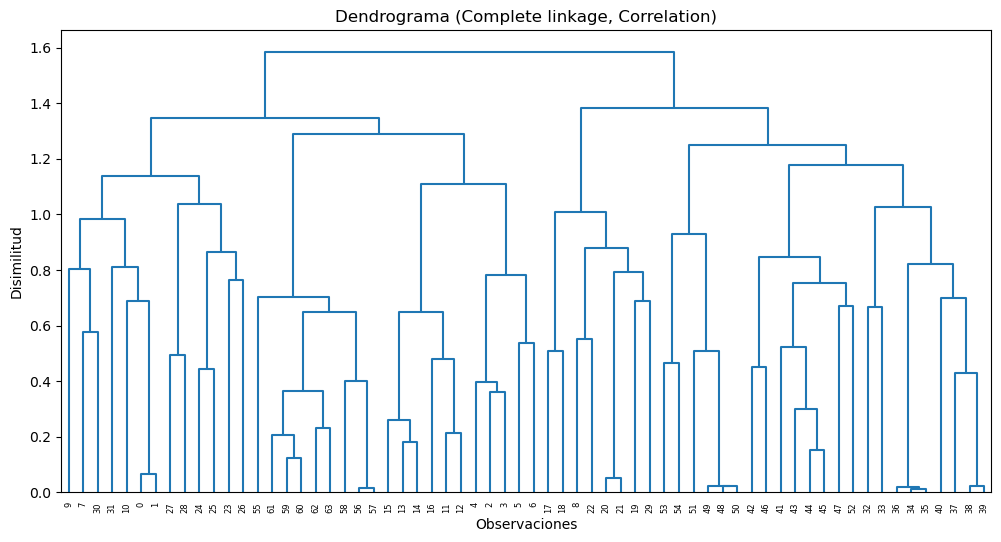

In [23]:
from scipy.cluster.hierarchy import linkage

# Hierarchical clustering con correlación
Z_corr = linkage(X_pca, method='complete', metric='correlation')

# Dendrograma monocromático
plt.figure(figsize=(12, 6))

dendrogram(Z_corr, color_threshold=0)

plt.title('Dendrograma (Complete linkage, Correlation)')
plt.xlabel('Observaciones')
plt.ylabel('Disimilitud')
plt.show()

Al cambiar la métrica de distancia de euclidiana a correlación, se observa una modificación en la estructura del dendrograma. A diferencia del caso anterior, la escala de disimilitud es menor y las uniones entre observaciones ocurren de manera más uniforme. Esto se debe a que la correlación mide similitud en patrones de comportamiento, en lugar de la magnitud absoluta de los datos.

Como resultado, el agrupamiento refleja qué tan similares son las tendencias en la expresión genética entre las muestras, en lugar de cuánto difieren en valores numéricos. Esto puede ser más apropiado en contextos como el análisis genético, donde interesa identificar perfiles similares más que niveles absolutos.

Aunque el dendrograma monocromático no permite distinguir visualmente clusters de forma inmediata, sí permite comparar la estructura global con la obtenida usando distancia euclidiana.

3.6 Cambio de linkage: average (euclidean)

En esta sección se analizará el efecto de cambiar el método de linkage utilizado en el clustering jerárquico. A diferencia del método complete linkage, que considera la mayor distancia entre elementos de dos clusters, el método average linkage utiliza el promedio de las distancias entre todos los pares de observaciones de ambos grupos.

Este cambio afecta la forma en que se construyen los clusters, ya que average linkage tiende a generar agrupaciones más balanceadas y menos influenciadas por valores extremos. En esta ocasión, se mantendrá la métrica de distancia euclidiana para aislar el efecto del cambio en el método de linkage.

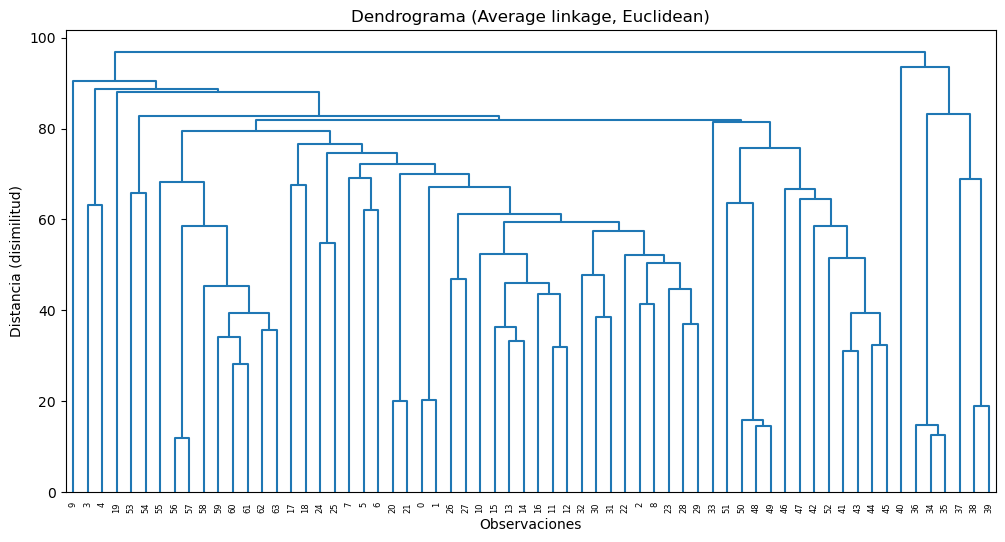

In [24]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Hierarchical clustering con average linkage
Z_avg = linkage(X_pca, method='average', metric='euclidean')

# Dendrograma monocromático
plt.figure(figsize=(12, 6))

dendrogram(Z_avg, color_threshold=0)

plt.title('Dendrograma (Average linkage, Euclidean)')
plt.xlabel('Observaciones')
plt.ylabel('Distancia (disimilitud)')
plt.show()

La estructura del árbol parece menos equilibrada, con una mayor concentración de observaciones en una de las ramas principales, lo que genera una distribución más asimétrica en comparación con el método anterior.

El método average linkage calcula la disimilitud entre clusters como el promedio de todas las distancias entre sus observaciones, lo que tiende a suavizar el efecto de valores extremos. Como resultado, las agrupaciones pueden ser más graduales, pero también menos claramente separadas en algunos casos.

En comparación con complete linkage, donde las agrupaciones suelen ser más compactas y definidas, el método average puede generar estructuras más difusas, lo que explica la apariencia más “extendida” o irregular del dendrograma. Esto demuestra que la elección del método de linkage influye directamente en la forma de los clusters y en la interpretación de los resultados.

4. Conclusión

A lo largo de este trabajo se analizaron dos enfoques de clustering ampliamente utilizados: K-Means y clustering jerárquico, aplicados tanto en un entorno controlado como en un dataset real de alta dimensionalidad. La implementación manual de K-Means permitió entender de manera clara el funcionamiento del algoritmo, evidenciando cómo las asignaciones iniciales influyen en el resultado final y cómo el proceso iterativo conduce a la convergencia hacia una solución estable.

Al aplicar K-Means al dataset NCI60, se observó que la alta dimensionalidad dificulta la identificación directa de patrones, lo que hizo necesario el uso de PCA para reducir la dimensionalidad. Esta transformación permitió mejorar significativamente la separación de los clusters y facilitó la interpretación de los resultados, demostrando la importancia del preprocesamiento en problemas complejos.

Por otro lado, el clustering jerárquico ofreció una perspectiva diferente al permitir visualizar la estructura completa de los datos mediante dendrogramas. Se evidenció cómo la elección del nivel de corte afecta el número de clusters, así como el impacto que tienen la métrica de disimilitud y el método de linkage en la forma de las agrupaciones. Esto resalta la flexibilidad del método, pero también la necesidad de un análisis cuidadoso para seleccionar la configuración más adecuada.

Ambos métodos demostraron ser herramientas útiles para el análisis exploratorio de datos, cada uno con sus propias fortalezas. K-Means destaca por su simplicidad y eficiencia, mientras que el clustering jerárquico ofrece una mayor capacidad de interpretación estructural. La combinación de estos enfoques, junto con técnicas de reducción de dimensionalidad como PCA, permite obtener una comprensión más completa de los datos y sus posibles agrupaciones.